In [1]:
%pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import requests
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

## Data Scraping

In [3]:
url = "https://zootopia.fandom.com/api.php"

params = {
    "action": "parse",
    "page": "Zootopia/Transcript",
    "format": "json"
}

response = requests.get(url, params = params)
data = response.json()
html = data["parse"]["text"]["*"]

soup = BeautifulSoup(html, "html.parser")

paragraphs = soup.find_all("p")

texts = []

for p in paragraphs:
    texts.append(p.get_text())
    print(p.get_text())

"Disney Presents"
[In a jungle, a little, feral bunny is creeping up to a water hole. During the following line, a tiger is stalking the rabbit.]

Young Judy Hopps: [initially hushed, her voice gradually increasing in volume] Fear, treachery, blood lust. Thousands of years ago, these were the forces that ruled our world. A world where prey were scared of predators. And predators had an uncontrollable, biological urge to maim and maul, and-

[The rabbit drinks from the water hole, notices, and turns around just when the tiger pounces towards it. Cut to reality. It is revealed that the "jungle" is really a stage in an auditorium, and as for the hunting, Jaguar, in a tiger costume, is pretending to pounce on a young Judy Hopps, who is wearing gray and white clothes that match her fur.]

Young Judy Hopps: Ahh! [she draws out long, red ribbons from her costume] Blood, blood, blood! [Judy falls on her back, making choking noises. She reaches for a hidden ketchup bottle and, while still layin

## Convert plain text into a DataFrame

In [4]:
df = pd.DataFrame(texts, columns = ["Text"])

df.head()

,Text
0,"""Disney Presents"""
1,"[In a jungle, a little, feral bunny is creepin..."
2,"Young Judy Hopps: [initially hushed, her voice..."
3,"[The rabbit drinks from the water hole, notice..."
4,"Young Judy Hopps: Ahh! [she draws out long, re..."


In [5]:
df[["Character", "Dialogue"]] = df["Text"].str.split(":", n = 1, expand = True)

df.head()

,Text,Character,Dialogue
0,"""Disney Presents""","""Disney Presents""",None
1,"[In a jungle, a little, feral bunny is creepin...","[In a jungle, a little, feral bunny is creepin...",None
2,"Young Judy Hopps: [initially hushed, her voice...",Young Judy Hopps,"[initially hushed, her voice gradually increa..."
3,"[The rabbit drinks from the water hole, notice...","[The rabbit drinks from the water hole, notice...",None
4,"Young Judy Hopps: Ahh! [she draws out long, re...",Young Judy Hopps,"Ahh! [she draws out long, red ribbons from he..."


## Data Cleaning & Data Preprocessing

In [6]:
def remove_special_characters(text):
    text = re.sub(r'[^\w\s:.!?]|_', '', text)
    return text

In [7]:
def normalize_character_name(character):
    character = character.strip().lower()

    if character in ["judy", "judy hopps voice", "judy hopps  nick wilde", "young judy hopps"]:
        return "judy hopps"
    
    if character in ["young nick wilde", "nick wildes voice", "judy hopps  nick wilde"]:
        return "nick wilde"
    
    if character == "dawn bellwethers voice":
        return "dawn bellwether"
    
    if character in ["clawhauser voice", "clawhauser"]:
        return "benjamin clawhauser"
    
    else:
        return character

In [8]:
noise_characters = [
    "gazelle app",
    "beaver reporter 2"
]

def remove_noise_characters(text):
    if text in noise_characters:
        return None
    else:
        return text

In [9]:
df = df.dropna(subset = ["Character", "Dialogue"])

df.head()

,Text,Character,Dialogue
2,"Young Judy Hopps: [initially hushed, her voice...",Young Judy Hopps,"[initially hushed, her voice gradually increa..."
4,"Young Judy Hopps: Ahh! [she draws out long, re...",Young Judy Hopps,"Ahh! [she draws out long, red ribbons from he..."
6,"Young Judy Hopps: Back then, the world was div...",Young Judy Hopps,"Back then, the world was divided in two - vic..."
7,"Sharla: Yeah, I don't have to cower in a herd ...",Sharla,"Yeah, I don't have to cower in a herd anymore..."
8,Jaguar: [slightly monotone from nervousness] I...,Jaguar,[slightly monotone from nervousness] I don't ...


In [10]:
df['Character'] = df['Character'].apply(remove_special_characters)
df['Dialogue'] = df['Dialogue'].apply(remove_special_characters)

In [11]:
df["Character"] = df["Character"].apply(normalize_character_name).apply(remove_noise_characters)

df.head()

,Text,Character,Dialogue
2,"Young Judy Hopps: [initially hushed, her voice...",judy hopps,initially hushed her voice gradually increasi...
4,"Young Judy Hopps: Ahh! [she draws out long, re...",judy hopps,Ahh! she draws out long red ribbons from her ...
6,"Young Judy Hopps: Back then, the world was div...",judy hopps,Back then the world was divided in two vicio...
7,"Sharla: Yeah, I don't have to cower in a herd ...",sharla,Yeah I dont have to cower in a herd anymore. ...
8,Jaguar: [slightly monotone from nervousness] I...,jaguar,slightly monotone from nervousness I dont hav...


In [12]:
counts = df['Character'].value_counts()

In [13]:
df = df[df['Character'].isin(counts[counts >= 3].index)]

In [14]:
df = df.dropna(subset = ["Character", "Dialogue"])

df.head()

,Text,Character,Dialogue
2,"Young Judy Hopps: [initially hushed, her voice...",judy hopps,initially hushed her voice gradually increasi...
4,"Young Judy Hopps: Ahh! [she draws out long, re...",judy hopps,Ahh! she draws out long red ribbons from her ...
6,"Young Judy Hopps: Back then, the world was div...",judy hopps,Back then the world was divided in two vicio...
7,"Sharla: Yeah, I don't have to cower in a herd ...",sharla,Yeah I dont have to cower in a herd anymore. ...
9,Young Judy Hopps: And I can make the world a b...,judy hopps,And I can make the world a better place I am ...


In [15]:
df["Character"] = df["Character"].str.title()

df.head()

,Text,Character,Dialogue
2,"Young Judy Hopps: [initially hushed, her voice...",Judy Hopps,initially hushed her voice gradually increasi...
4,"Young Judy Hopps: Ahh! [she draws out long, re...",Judy Hopps,Ahh! she draws out long red ribbons from her ...
6,"Young Judy Hopps: Back then, the world was div...",Judy Hopps,Back then the world was divided in two vicio...
7,"Sharla: Yeah, I don't have to cower in a herd ...",Sharla,Yeah I dont have to cower in a herd anymore. ...
9,Young Judy Hopps: And I can make the world a b...,Judy Hopps,And I can make the world a better place I am ...


In [16]:
df["Dialogue"] = df["Dialogue"].str.lower()

In [17]:
df = df.drop(columns = ["Text"]).reset_index(drop = True)

df.head()

,Character,Dialogue
0,Judy Hopps,initially hushed her voice gradually increasi...
1,Judy Hopps,ahh! she draws out long red ribbons from her ...
2,Judy Hopps,back then the world was divided in two vicio...
3,Sharla,yeah i dont have to cower in a herd anymore. ...
4,Judy Hopps,and i can make the world a better place i am ...


## Statistical Analysis

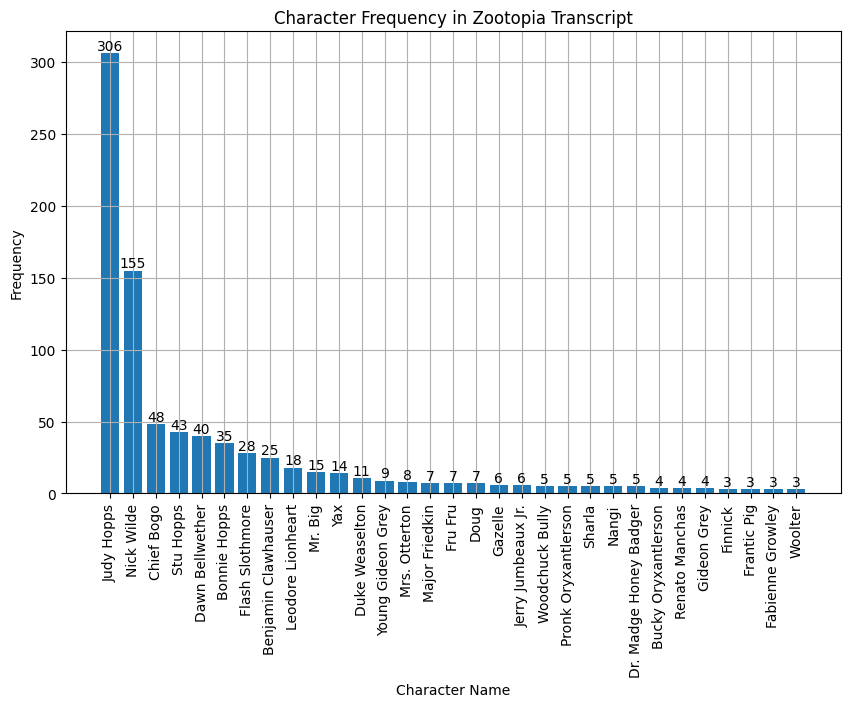

In [18]:
plt.figure(figsize = (10, 6))
plt.bar(df["Character"].value_counts().index, df["Character"].value_counts().values)

for i, val in enumerate(df["Character"].value_counts().values):
    plt.text(i, val, str(val), ha = 'center', va = 'bottom')

plt.xlabel("Character Name")
plt.ylabel("Frequency")
plt.title("Character Frequency in Zootopia Transcript")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()

## Sentiment Analysis

In [19]:
def sentiment_score_convert(scores):
    if scores > 0.05:
        return "Positive"
    elif scores < -0.05:
        return "Negative"
    else:
        return "Neutral"

In [20]:
sentiment = SentimentIntensityAnalyzer()

df["Sentiment"] = df["Dialogue"].apply(lambda x: sentiment.polarity_scores(x)["compound"])

df["Sentiment Category"] = df["Sentiment"].apply(sentiment_score_convert)

df.head()

,Character,Dialogue,Sentiment,Sentiment Category
0,Judy Hopps,initially hushed her voice gradually increasi...,-0.8225,Negative
1,Judy Hopps,ahh! she draws out long red ribbons from her ...,-0.8007,Negative
2,Judy Hopps,back then the world was divided in two vicio...,0.6369,Positive
3,Sharla,yeah i dont have to cower in a herd anymore. ...,0.7088,Positive
4,Judy Hopps,and i can make the world a better place i am ...,0.3164,Positive


In [21]:
result = df.groupby('Character')['Sentiment'].mean().sort_values(ascending = False)

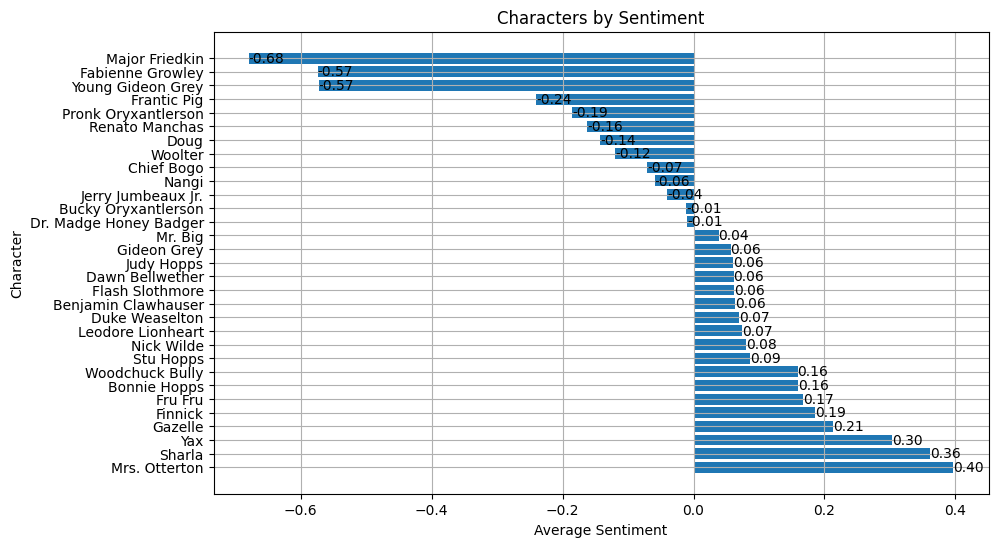

In [22]:
plt.figure(figsize = (10, 6))
plt.barh(result.index, result.values)

for i, val in enumerate(result.values):
    plt.text(val, i, f"{val:.2f}", va='center')

plt.xlabel("Average Sentiment")
plt.ylabel("Character")
plt.title("Characters by Sentiment")
plt.grid(True)
plt.show()

In [23]:
characters_df = df.groupby('Character')['Sentiment'].mean().sort_values(ascending = False).reset_index()

characters_df["Sentiment Category"] = characters_df["Sentiment"].apply(sentiment_score_convert)

characters_df

,Character,Sentiment,Sentiment Category
0,Mrs. Otterton,0.396962,Positive
1,Sharla,0.361820,Positive
2,Yax,0.303979,Positive
3,Gazelle,0.213000,Positive
4,Finnick,0.186367,Positive
5,Fru Fru,0.167943,Positive
6,Bonnie Hopps,0.160429,Positive
7,Woodchuck Bully,0.158960,Positive
8,Stu Hopps,0.086853,Positive
9,Nick Wilde,0.080435,Positive


In [24]:
stack = df.groupby(["Character", "Sentiment Category"]).size().unstack()

stack = stack.fillna(0).astype(int)

stack

Sentiment Category,Negative,Neutral,Positive
Character,,,
Benjamin Clawhauser,7,8,10
Bonnie Hopps,5,14,16
Bucky Oryxantlerson,1,2,1
Chief Bogo,19,18,11
Dawn Bellwether,14,7,19
Doug,4,1,2
Dr. Madge Honey Badger,2,0,3
Duke Weaselton,3,4,4
Fabienne Growley,2,0,1


In [25]:
characters_df.to_csv("character_sentiment_analysis.csv", index = False)

In [26]:
df.to_csv("zootopia_transcript_cleaned.csv", index = False)